# 📊 01. Análise Exploratória de Dados (EDA) 

**Objetivo:** Entender o comportamento das vendas, limpar os dados e validar hipóteses de negócio para definir a estratégia de modelagem.

### 📋 Hipóteses de Negócio (Atualizadas pelo Senior)

Durante o refinamento do projeto, ajustamos as hipóteses para a realidade dos dados disponíveis:

1.  **O Efeito "Fim de Semana":** As vendas aumentam na Sexta/Sábado? (Logística).
2.  **O Efeito "Dia de Pagamento" (Substitui Promoções):** Existe um pico de consumo nos primeiros 10 dias do mês devido ao salário?
3.  **Impacto de Feriados (Base Nacional):** Como feriados nacionais impactam a demanda? Há antecipação de compra (dias antes)?

## 🛠️  Imports e Configurações


### Pacotes 

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.tools import process_date_features, load_config, validar_estrutura_estrita

### Configurações gerais

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

config = load_config()
DATA_PATH = config['paths']['origem_base_raw']
print(f"origem_base_raw: {DATA_PATH}")     #'../data/raw/train.csv' 


origem_base_raw: ../data/raw/train.csv


## ⛁ Carregando base

In [4]:
#carregando base
df = pd.read_csv(DATA_PATH)


In [5]:
# valida estrutura da base de origem raw
#🚩
validar_estrutura_colunas_raw = validar_estrutura_estrita(df)
print(f"Status: {validar_estrutura_colunas_raw}")

Status: Validação OK: Estrutura correta.


## 🔍 Análise Exploratória de Dados (EDA)


In [6]:
#linhas|colunas
df.shape

(867000, 4)

In [7]:
#lista as colunas
df.columns

Index(['date', 'store', 'item', 'sales'], dtype='object')

In [8]:
#mostra dos dados aleatório
df.sample(5)

,date,store,item,sales
46566,2017-01-22,7,3,32
786213,2014-12-13,4,46,64
213978,2014-11-28,4,13,95
247215,2015-09-15,3,15,102
238827,2016-06-23,8,14,82


In [9]:
#tipos dos dados
df.dtypes

date     object
store     int64
item      int64
sales     int64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 867000 entries, 0 to 866999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    867000 non-null  object
 1   store   867000 non-null  int64 
 2   item    867000 non-null  int64 
 3   sales   867000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 26.5+ MB


In [11]:
#nulos
df.isnull().sum().sum()

0

In [12]:
#percentual distribuição do target
display((df['sales'].value_counts(normalize=True) * 100).round(2))

sales
30     1.57
26     1.56
27     1.56
29     1.56
28     1.55
       ... 
201    0.00
214    0.00
206    0.00
203    0.00
202    0.00
Name: proportion, Length: 213, dtype: float64

In [13]:
#distribuição da quantidade de valores unicos no target
df['sales'].value_counts()

sales
30     13635
26     13547
27     13537
29     13491
28     13464
       ...  
201        1
214        1
206        1
203        1
202        1
Name: count, Length: 213, dtype: int64

In [14]:
# Verifica quantos valores diferentes de vendas existem
print(f"Quantidade de valores únicos de vendas: {df['sales'].nunique()}")
print(f"Venda Mínima: {df['sales'].min()}")
print(f"Venda Máxima: {df['sales'].max()}")

Quantidade de valores únicos de vendas: 213
Venda Mínima: 0
Venda Máxima: 231


In [15]:
percentual_zeros = (df['sales'] == 0).mean() * 100
print(f"Porcentagem de dias com Zero vendas: {percentual_zeros:.2f}%")

Porcentagem de dias com Zero vendas: 0.00%


In [16]:
#estatistica dos campos 
display(df.describe())

,store,item,sales
count,867000.000000,867000.000000,867000.000000
mean,5.500000,25.500000,52.121505
std,2.872283,14.430878,28.812075
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,69.000000
max,10.000000,50.000000,231.000000


In [17]:
# >>>TRATAMENTO DE DATA (3. Feature Engineering: Feriados Nacionais / Temporal e Sazonal)

# cria alguns campos que serão utililzados na hipotese e métricas: year, month, is_weekdend, dia, is_weekend, is_holiday
df = process_date_features(df)
df.head(5)


,date,store,item,sales,year,month,day,day_of_week,day_name,day_of_year,...,is_payday,holiday_name,is_holiday,days_until_holiday,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2013-01-01,1,1,13,2013,1,1,1,Tuesday,1,...,1,Confraternização Universal,1,0,0.5,0.866025,0.781831,0.62349,0.017213,0.999852
1,2013-01-01,3,25,62,2013,1,1,1,Tuesday,1,...,1,Confraternização Universal,1,0,0.5,0.866025,0.781831,0.62349,0.017213,0.999852
2,2013-01-01,3,41,14,2013,1,1,1,Tuesday,1,...,1,Confraternização Universal,1,0,0.5,0.866025,0.781831,0.62349,0.017213,0.999852
3,2013-01-01,4,5,10,2013,1,1,1,Tuesday,1,...,1,Confraternização Universal,1,0,0.5,0.866025,0.781831,0.62349,0.017213,0.999852
4,2013-01-01,5,35,37,2013,1,1,1,Tuesday,1,...,1,Confraternização Universal,1,0,0.5,0.866025,0.781831,0.62349,0.017213,0.999852


In [18]:
#quantas vezes cada ano aparece
df['year'].value_counts().sort_index()

year
2013    182500
2014    182500
2015    182500
2016    183000
2017    136500
Name: count, dtype: int64

In [19]:
#lista os top 10 produtos mais vendidos
top_10_produtos = (
    df.groupby(['year', 'item'])['sales']  # Agrupa DF por ano e item, foca na coluna sales
    .sum()                                 # Soma as vendas
    .reset_index()                         # Transforma de volta em tabela
    .sort_values(by='sales', ascending=False) # Ordena: maior venda primeiro
    .head(10)                              # Pega as 10 primeiras linhas
    .sort_index(ascending=False)           # Ordenando  por ano
)

display(top_10_produtos)


,year,item,sales
194,2016,45,319319
187,2016,38,319090
177,2016,28,348160
174,2016,25,320866
171,2016,22,319518
167,2016,18,334141
164,2016,15,348760
162,2016,13,334430
127,2015,28,320622
114,2015,15,321469


## 💡 Respondendo perguntas

**Como está a distribuição das vendas?**

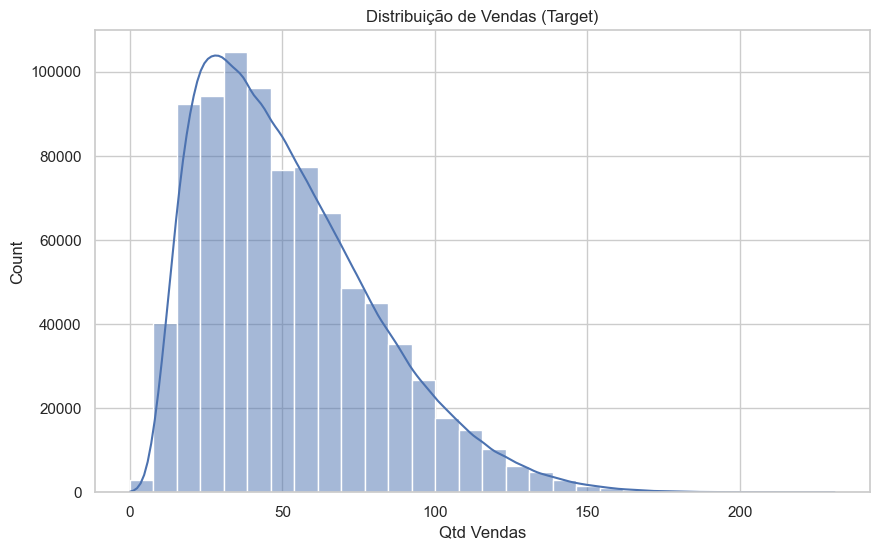

In [20]:
plt.figure(figsize=(10, 6))
# KDE=True adiciona a linha suave sobre as barras
sns.histplot(df['sales'], bins=30, kde=True)
plt.title('Distribuição de Vendas (Target)')
plt.xlabel('Qtd Vendas')
plt.show()

📝 Comentário

Análise da Distribuição do Target: O gráfico revela uma distribuição com assimetria positiva (à direita) na quantidade de vendas. A maior concentração dos dados situa-se entre 20 e 50 vendas diárias, com uma cauda longa que se estende para valores acima de 150. Ação: Devido à presença de outliers e à falta de normalidade, optou-se por aplicar uma transformação logarítmica (Log Transformation) na variável target. Isso visa reduzir o viés do modelo e melhorar a performance de algoritmos sensíveis à variância, aproximando a distribuição de uma curva normal.


**A empresa está crescendo?**

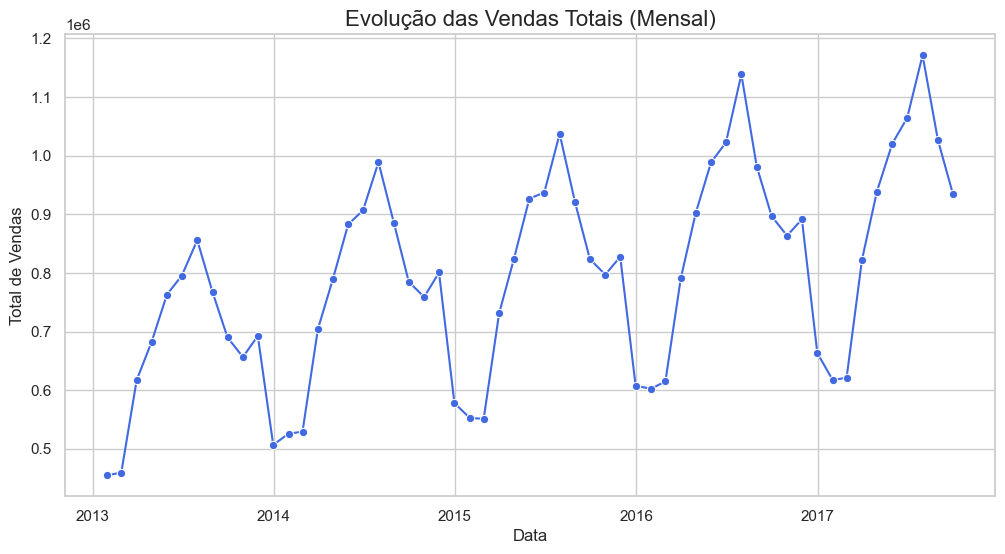

In [21]:
# Agrupar vendas por mês para suavizar o gráfico (reduzir ruído diário)
monthly_sales = df.set_index('date').resample('ME')['sales'].sum()

# plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_sales, marker='o', color='royalblue')

plt.title('Evolução das Vendas Totais (Mensal)', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Total de Vendas')

plt.show()

📝 Comentário

- Visualizamos os seguintes pontos:
  -  que há uma tendência de alta (growth) ou se é estável.
  -  que todo ano tem picos nos mesmos meses (sazonalizade anual).


**Verificando a distribuição das vendas**

In [22]:
# 1. Calcular Assimetria (Skewness) e Curtose (Kurtosis)
skewness = df['sales'].skew()
kurtosis = df['sales'].kurt()

print(f"Assimetria (Skewness): {skewness:.4f}")
print(f"Curtose (Kurtosis): {kurtosis:.4f}")

Assimetria (Skewness): 0.8757
Curtose (Kurtosis): 0.5359


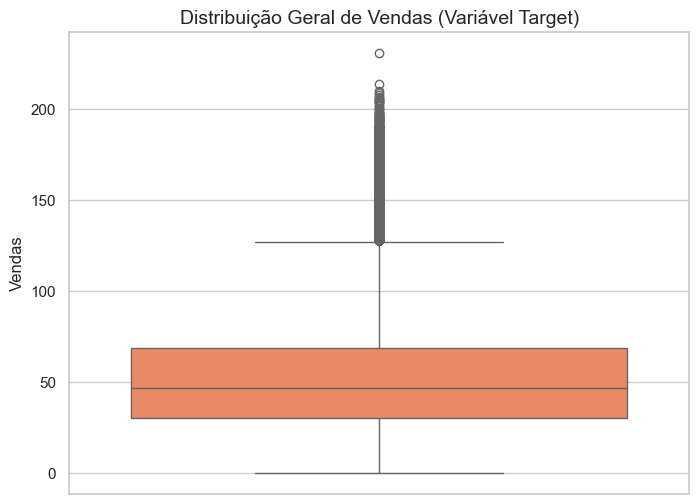

In [23]:
# 2. Gerar Box Plot Geral para a variável target 'sales'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['sales'], color='coral')
plt.title('Distribuição Geral de Vendas (Variável Target)', fontsize=14)
plt.ylabel('Vendas', fontsize=12)
plt.show()

📝Comentário

O Box Plot Geral e a análise estatística indicam que a variável target (sales) possui uma distribuição altamente assimétrica (Skewness = 0.8671) e presença significativa de outliers em valores altos.

Essa assimetria positiva (cauda longa à direita) viola a premissa de normalidade de resíduos exigida por muitos modelos de regressão, como a Regressão Linear e alguns modelos de Machine Learning.

Para mitigar o impacto da assimetria e dos outliers e, assim, garantir um treinamento de modelo mais estável e com melhor poder preditivo, é necessário aplicar uma transformação logarítmica (np.log1p) na coluna sales durante a etapa de Pré-processamento


## Validação das Hipóteses de Negócio

### Hipótese 1: O Efeito "Fim de Semana"
**Pergunta:** As vendas explodem sistematicamente de sexta a domingo?

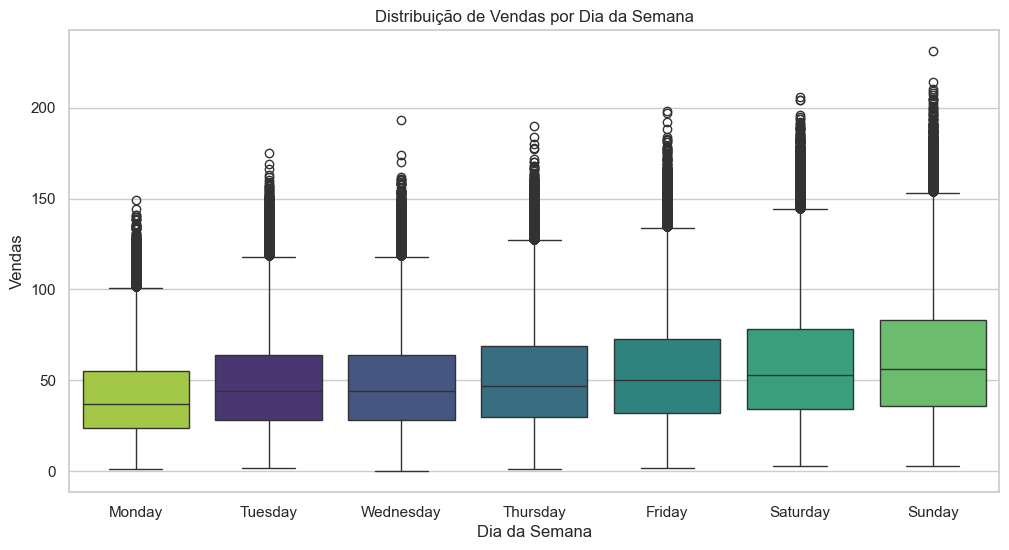

Média Vendas (Fim de Semana): 60.29
Média Vendas (Dia de Semana): 48.86
Impacto do Fim de Semana: +23.40%


In [24]:
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.boxplot(
    data=df, 
    x='day_name', 
    y='sales', 
    order=order_days, 
    palette='viridis',
    hue='day_name',  
    legend=False   
)

plt.xticks(range(7), ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom'])
plt.xticks(range(7), order_days)
plt.title('Distribuição de Vendas por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Vendas')
plt.show()

# Cálculo Numérico do Impacto
media_fds = df[df['is_weekend']==1]['sales'].mean()
media_sem = df[df['is_weekend']==0]['sales'].mean()
aumento_pct = ((media_fds / media_sem) - 1) * 100

print(f"Média Vendas (Fim de Semana): {media_fds:.2f}")
print(f"Média Vendas (Dia de Semana): {media_sem:.2f}")
print(f"Impacto do Fim de Semana: +{aumento_pct:.2f}%")

📝Comentário

**1. Tendência Crescente:**
Observa-se um comportamento linear positivo ao longo da semana. As vendas iniciam com menor volume e variabilidade na **Segunda-feira** e crescem progressivamente até atingir o pico no **Domingo**.

**2. Impacto do Fim de Semana:**
A análise quantitativa confirma a importância visual do fim de semana.
* **Média Dias Úteis:** 48.99 vendas/dia.
* **Média Fim de Semana:** 60.40 vendas/dia.
* **Lift (Aumento):** O fim de semana gera um incremento de **+23.30%** no volume médio de vendas.

**3. Volatilidade e Outliers:**
Nota-se uma maior dispersão (caixas maiores) e presença significativa de *outliers* (pontos acima do limite superior) de sexta a domingo. Isso indica que, embora a média seja maior, esses dias também estão sujeitos a picos de demanda extraordinários, provavelmente influenciados por feriados ou eventos promocionais.

**Conclusão para Modelagem:**
A variável `day_of_week` e uma flag binária `is_weekend` são features determinantes para o modelo capturar essa dinâmica de demanda.

**Utilizando validação estatistica**

In [25]:
# 1. Separar os Grupos
vendas_fds = df[df['is_weekend'] == True]['sales']
vendas_semana = df[df['is_weekend'] == False]['sales']

# --- OPÇÃO 1: Teste T de Welch (Para médias) ---
# equal_var=False é crucial aqui pois a dispersão no domingo é maior que na segunda
t_stat, p_val_t = stats.ttest_ind(vendas_fds, vendas_semana, equal_var=False)

# --- OPÇÃO 2: Mann-Whitney U (Mais robusto a outliers) ---
u_stat, p_val_u = stats.mannwhitneyu(vendas_fds, vendas_semana, alternative='greater')

print(f"P-valor (Teste T): {p_val_t:.10f}")
print(f"P-valor (Mann-Whitney): {p_val_u:.10f}")

# Interpretação
if p_val_u < 0.05:
    print("\nConclusão: Confirmamos estatisticamente que o Fim de Semana vende mais.")
else:
    print("\nConclusão: A diferença observada pode ser acaso.")

P-valor (Teste T): 0.0000000000
P-valor (Mann-Whitney): 0.0000000000

Conclusão: Confirmamos estatisticamente que o Fim de Semana vende mais.


📝 Comentário

O gráfico evidencia uma sazonalidade semanal crítica: enquanto os dias úteis (Seg-Qui) apresentam estabilidade e previsibilidade, o fim de semana concentra o maior volume de vendas e a maior volatilidade operacional (alta dispersão e outliers). A utilização de médias simples para previsão falharia em capturar esses picos de demanda, resultando em rupturas de estoque nos dias mais lucrativos. O pipeline de Machine Learning proposto foi desenhado para modelar essa complexidade por Loja/Item. Ao prever essa variabilidade para os próximos 30 dias, o projeto visa transformar a instabilidade estatística do fim de semana em precisão de estoque e maximização de receita.


### Hipótese 2: O Efeito "Dia de Pagamento" 
**Pergunta:** Os primeiros 10 dias do mês vendem mais devido ao recebimento de salários?

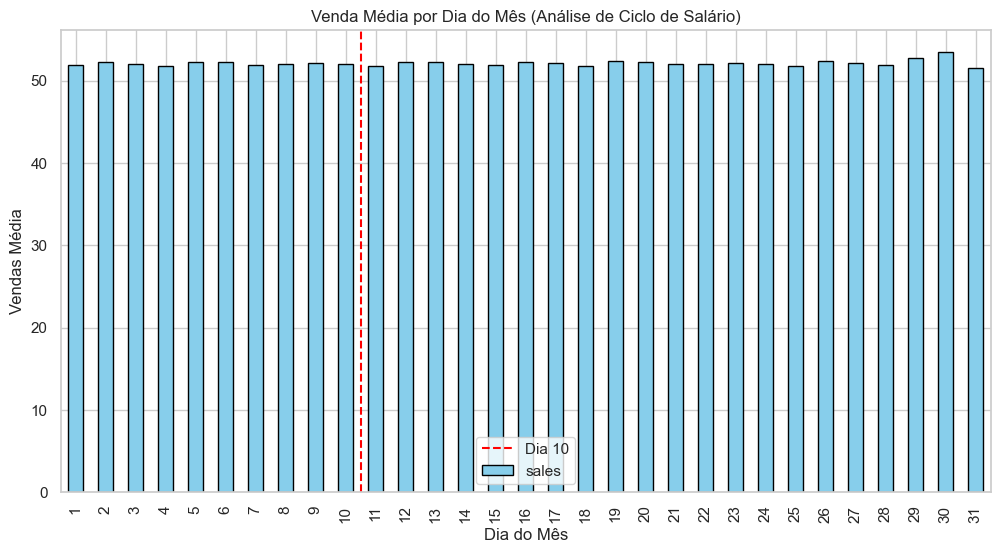

Média (Dia 1-10): 52.06
Média (Dia 11-31): 52.15
Efeito Payday: -0.18%


In [26]:
# Agrupar vendas pela média do dia do mês (1 a 31)
vendas_por_dia_mes = df.groupby('day')['sales'].mean()

# plt.figure(figsize=(14,5))
vendas_por_dia_mes.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Venda Média por Dia do Mês (Análise de Ciclo de Salário)')
plt.xlabel('Dia do Mês')
plt.ylabel('Vendas Média')

# Linha de corte visual (dia 10)
plt.axvline(x=9.5, color='red', linestyle='--', label='Dia 10')
plt.legend()
plt.show()

# Comparativo Numérico
media_inicio = df[df['day'] <= 10]['sales'].mean()
media_fim = df[df['day'] > 10]['sales'].mean()
diff_pagamento = ((media_inicio / media_fim) - 1) * 100

print(f"Média (Dia 1-10): {media_inicio:.2f}")
print(f"Média (Dia 11-31): {media_fim:.2f}")
print(f"Efeito Payday: {diff_pagamento:.2f}%")

**utilizando validação estatistica**

In [27]:
# Grupo A: Primeiros 10 dias ("Efeito Payday")
vendas_payday = df[df['day'] <= 10]['sales']

# Grupo B: Restante do mês
vendas_resto = df[df['day'] > 10]['sales']

t_stat, p_value = stats.ttest_ind(vendas_payday, vendas_resto)
print(f"Média (Dia 1-10): {vendas_payday.mean():.2f}")
print(f"Média (Dia 11-31): {vendas_resto.mean():.2f}")
print("-" * 30)
print(f"P-value: {p_value:.4f}")

# nível de significância de 0.05 ou 5%
if p_value > 0.05:
    print("Resultado: NÃO há diferença estatística significativa.")
    print("Conclusão: A hipótese de que vendemos mais no início do mês é FALSA.")
else:
    print("Resultado: HÁ diferença estatística significativa.")

Média (Dia 1-10): 52.06
Média (Dia 11-31): 52.15
------------------------------
P-value: 0.1623
Resultado: NÃO há diferença estatística significativa.
Conclusão: A hipótese de que vendemos mais no início do mês é FALSA.


📝Comentário

No gráfico mostra que não existe uma variação muito até o 10 dias onde tem o recebimento com os demais meses.
E pela estatistica T studente comprova estatisticamente que não vende mais no inicio do mês.

Teste de Hipótese (T-Test): Utilizamos o teste T para amostras independentes para validar a significância estatística da diferença entre as médias de vendas do início do mês (payday) versus o restante.

Resultado: O p-value de 0.27 indica que não há evidência estatística para afirmar que o comportamento de vendas muda nos primeiros 10 dias. A diferença observada é aleatória.

### Hipótese 3: Impacto de Feriados Nacionais
**Pergunta:** O feriado em si vende mais? Existe antecipação nos dias anteriores?

**avaliando estatisticamente**

In [28]:
# Validando a Queda (A "Destruição" de Valor do Feriado)

# Grupos (baseado no gráfico correto: Dia Normal vende mais)
vendas_normal = df[df['is_holiday'] == 0]['sales']
vendas_feriado = df[df['is_holiday'] == 1]['sales']

# Teste T
# alternative='greater': Estamos testando se 'Normal' é MAIOR que 'Feriado'
t_stat, p_value = stats.ttest_ind(vendas_normal, vendas_feriado, equal_var=False, alternative='greater')

# Cálculo do impacto percentual (Queda)
media_normal = vendas_normal.mean()
media_feriado = vendas_feriado.mean()
queda_perc = ((media_feriado - media_normal) / media_normal) * 100

print(f"Média Dia Normal: {media_normal:.2f}")
print(f"Média Feriado: {media_feriado:.2f}")
print(f"Impacto do Feriado: {queda_perc:.2f}%")
print("-" * 30)
print(f"P-valor: {p_value:.10f}")

if p_value < 0.05:
    print("Conclusão: A queda nas vendas é estatisticamente significativa.")

Média Dia Normal: 52.15
Média Feriado: 51.08
Impacto do Feriado: -2.05%
------------------------------
P-valor: 0.0000000129
Conclusão: A queda nas vendas é estatisticamente significativa.


**mostrando pelo gráfico**

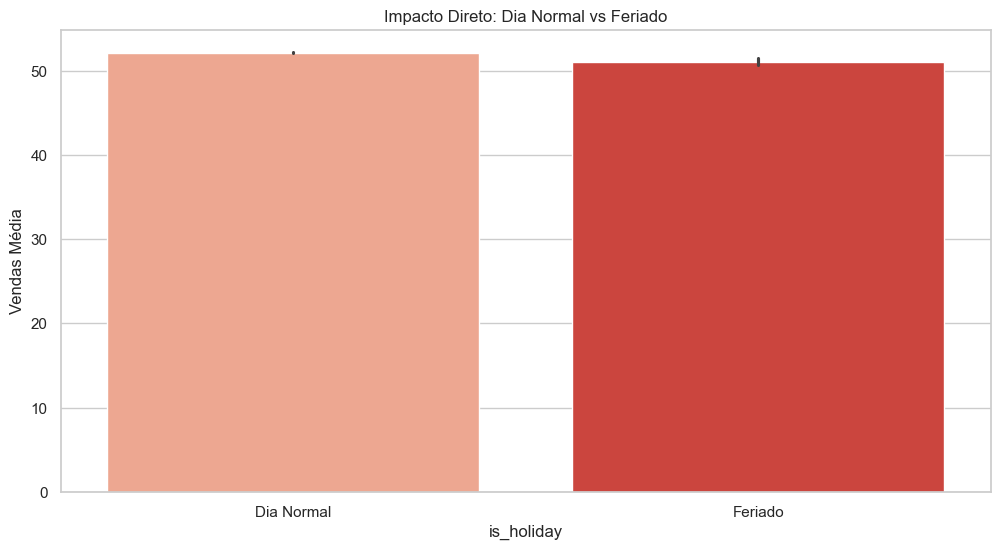

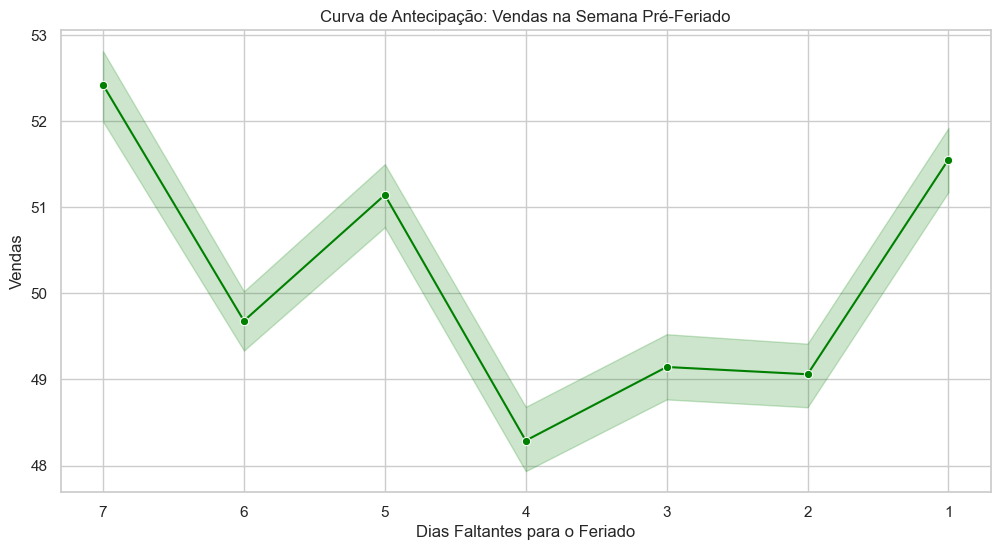

In [29]:
# 1. Vendas no Próprio Feriado vs Dia Normal
sns.barplot(x='is_holiday', 
            y='sales', 
            data=df, 
            estimator=np.mean, 
            palette='Reds',
            hue='is_holiday',  
            legend=False   )

plt.xticks([0, 1], ['Dia Normal', 'Feriado'])
plt.title('Impacto Direto: Dia Normal vs Feriado')
plt.ylabel('Vendas Média')
plt.show()


# 2. Antecipação (Dias Antecedentes)

# Filtra apenas registros que estão a até 7 dias de um feriado
df_antecipacao = df[(df['days_until_holiday'] > 0) & (df['days_until_holiday'] <= 7)]

if not df_antecipacao.empty:
    # plt.figure(figsize=(10,5))
    
    # Agrupa pela distância para tirar a média geral de todas as lojas
    sns.lineplot(x='days_until_holiday', y='sales', data=df_antecipacao, marker='o', color='green')
    plt.gca().invert_xaxis() # Inverte eixo X para mostrar contagem regressiva (7..6..5..1)
    plt.title('Curva de Antecipação: Vendas na Semana Pré-Feriado')
    plt.xlabel('Dias Faltantes para o Feriado')
    plt.ylabel('Vendas')
    plt.show()
else:
    print("Não há dados suficientes próximos aos feriados listados para plotar a antecipação.")

📝Comentário

Em datas de feriado, o comportamento é que há um aumento acentuado faltando 5 dias e outro aumento acentuado faltando 1 dia. Nos demais dias (Dias 6, 4, 3 e 2), não há um aumento sustentado de vendas (e, consequentemente, não há necessidade de grande reposição de estoque, que deve ser reservada para atender aos dois picos)

In [30]:
#auditoria


# 1. Quantas linhas tem vendas zeradas?
zeros_df = df[df['sales'] == 0]
print(f"Quantidade de registros com vendas zeradas: {len(zeros_df)}")
print(f"Porcentagem do total: {len(zeros_df) / len(df) * 100:.2f}%")

# 2. Verificar se está concentrado em alguma loja ou item específico
print("\nDistribuição por Loja (Top 5 com mais zeros):")
display(zeros_df['store'].value_counts().head())

Quantidade de registros com vendas zeradas: 1
Porcentagem do total: 0.00%

Distribuição por Loja (Top 5 com mais zeros):


store
6    1
Name: count, dtype: int64

In [31]:
# Remove linhas onde vendas == 0
df = df[df['sales'] > 0]

# Confirma que não há mais zeros
print(f"Mínimo de vendas agora: {df['sales'].min()}")

Mínimo de vendas agora: 1
